In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
# for reproducible results
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [ ]:
# 1. Dataset Preparation

# Flattening: Logistic Regression needs a plain feature vector, not a 2D image.
# Scaling: helps both models train faster and more stably.

(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.mnist.load_data()

def filter_zeros_and_ones(X, y):
    mask = (y == 0) | (y == 1)
    X = X[mask]
    y = y[mask]
    # flatten 28x28 -> 784, scale 0-255 -> 0-1
    X = X.reshape(len(X), 28 * 28).astype('float32') / 255.0
    return X, y

X_train, y_train = filter_zeros_and_ones(X_train_full, y_train_full)
X_test, y_test = filter_zeros_and_ones(X_test_full, y_test_full)

print("Training set shape:", X_train.shape, "| Test set shape:", X_test.shape)
print("Training class balance -> 0s:", np.sum(y_train == 0), " 1s:", np.sum(y_train == 1))
print("Test class balance     -> 0s:", np.sum(y_test == 0), " 1s:", np.sum(y_test == 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (12665, 784) | Test set shape: (2115, 784)
Training class balance -> 0s: 5923  1s: 6742
Test class balance     -> 0s: 980  1s: 1135


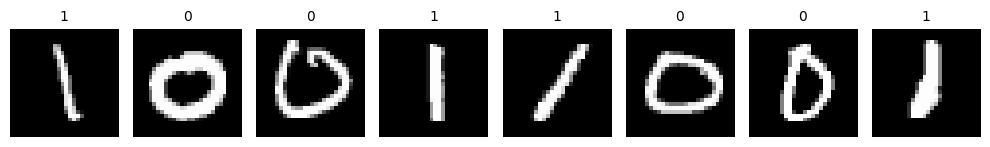

In [ ]:
# A quick look at the data
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
idx = np.random.choice(len(X_train), 8, replace=False)
for ax, i in zip(axes, idx):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(int(y_train[i])), fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 2. Discriminative Model — Logistic Regression
# A discriminative model learns the boundary that separates classes — it answers "is this a 0 or a 1?"

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Discriminative model (Logistic Regression) test accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

Discriminative model (Logistic Regression) test accuracy: 0.9995

Confusion Matrix:
 [[ 979    1]
 [   0 1135]]

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.9990    0.9995       980
           1     0.9991    1.0000    0.9996      1135

    accuracy                         0.9995      2115
   macro avg     0.9996    0.9995    0.9995      2115
weighted avg     0.9995    0.9995    0.9995      2115



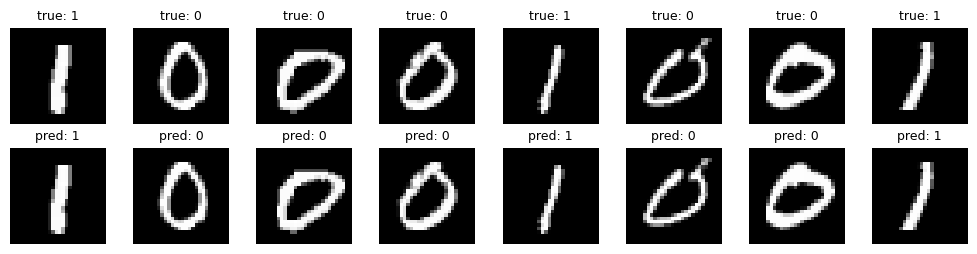

In [ ]:
# Visualizing predictions
fig, axes = plt.subplots(2, 8, figsize=(10, 2.6))
idx2 = np.random.choice(len(X_test), 8, replace=False)
for k, i in enumerate(idx2):
    axes[0, k].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[0, k].set_title(f"true: {int(y_test[i])}", fontsize=9)
    axes[0, k].axis('off')

    axes[1, k].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[1, k].set_title(f"pred: {int(y_pred[i])}", fontsize=9)
    axes[1, k].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 3. Generative Model — A Simple Autoencoder
# A generative model tries to learn the underlying data distribution — what 0s and 1s generally look like — so it can produce new, plausible images.
# Encoder: compresses a 784-pixel image into a 16-number latent vector
# Decoder: reconstructs the 784-pixel image from that latent vector

latent_dim = 16  # size of the compressed representation

encoder = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(latent_dim, activation='relu')
], name='encoder')

decoder = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(784, activation='sigmoid')  # sigmoid -> pixel values between 0 and 1
], name='decoder')

autoencoder = keras.Sequential([encoder, decoder], name='autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 16)             │       102,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       103,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,856 (804.12 KB)

 Trainable params: 205,856 (804.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=2
)

print(f"\nFinal train loss: {history.history['loss'][-1]:.5f} | Final val loss: {history.history['val_loss'][-1]:.5f}")

Epoch 1/15
99/99 - 2s - 22ms/step - loss: 0.0747 - val_loss: 0.0361
Epoch 2/15
99/99 - 1s - 8ms/step - loss: 0.0299 - val_loss: 0.0244
Epoch 3/15
99/99 - 1s - 9ms/step - loss: 0.0222 - val_loss: 0.0198
Epoch 4/15
99/99 - 1s - 12ms/step - loss: 0.0190 - val_loss: 0.0175
Epoch 5/15
99/99 - 1s - 12ms/step - loss: 0.0169 - val_loss: 0.0157
Epoch 6/15
99/99 - 2s - 16ms/step - loss: 0.0151 - val_loss: 0.0139
Epoch 7/15
99/99 - 1s - 15ms/step - loss: 0.0135 - val_loss: 0.0126
Epoch 8/15
99/99 - 2s - 19ms/step - loss: 0.0123 - val_loss: 0.0117
Epoch 9/15
99/99 - 1s - 8ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 10/15
99/99 - 1s - 8ms/step - loss: 0.0110 - val_loss: 0.0106
Epoch 11/15
99/99 - 1s - 12ms/step - loss: 0.0105 - val_loss: 0.0102
Epoch 12/15
99/99 - 1s - 8ms/step - loss: 0.0101 - val_loss: 0.0098
Epoch 13/15
99/99 - 1s - 8ms/step - loss: 0.0097 - val_loss: 0.0094
Epoch 14/15
99/99 - 1s - 8ms/step - loss: 0.0093 - val_loss: 0.0091
Epoch 15/15
99/99 - 1s - 8ms/step - loss: 0.0090 -

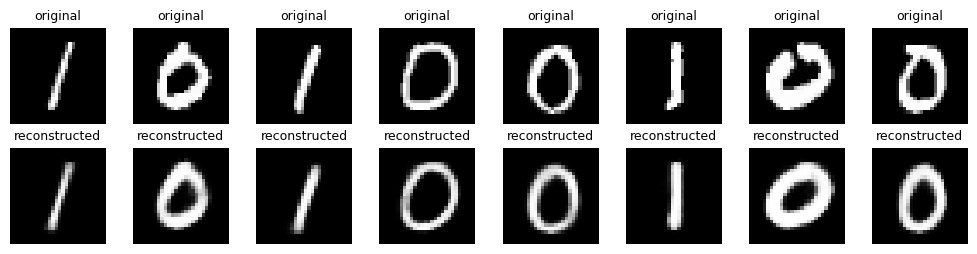

In [ ]:
# Reconstructions
reconstructed = autoencoder.predict(X_test[:8], verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(10, 2.6))
for k in range(8):
    axes[0, k].imshow(X_test[k].reshape(28, 28), cmap='gray')
    axes[0, k].set_title('original', fontsize=9)
    axes[0, k].axis('off')

    axes[1, k].imshow(reconstructed[k].reshape(28, 28), cmap='gray')
    axes[1, k].set_title('reconstructed', fontsize=9)
    axes[1, k].axis('off')
plt.tight_layout()
plt.show()

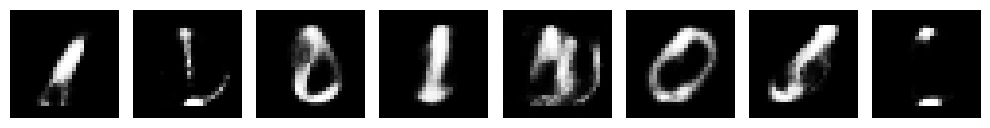

In [ ]:
latents = encoder.predict(X_train, verbose=0)
latent_mean = latents.mean(axis=0)
latent_std = latents.std(axis=0)

n_new = 8
random_latent_vectors = latent_mean + latent_std * np.random.randn(n_new, latent_dim) * 0.9
generated_images = decoder.predict(random_latent_vectors, verbose=0)

fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for k in range(8):
    axes[k].imshow(generated_images[k].reshape(28, 28), cmap='gray')
    axes[k].axis('off')
plt.tight_layout()
plt.show()

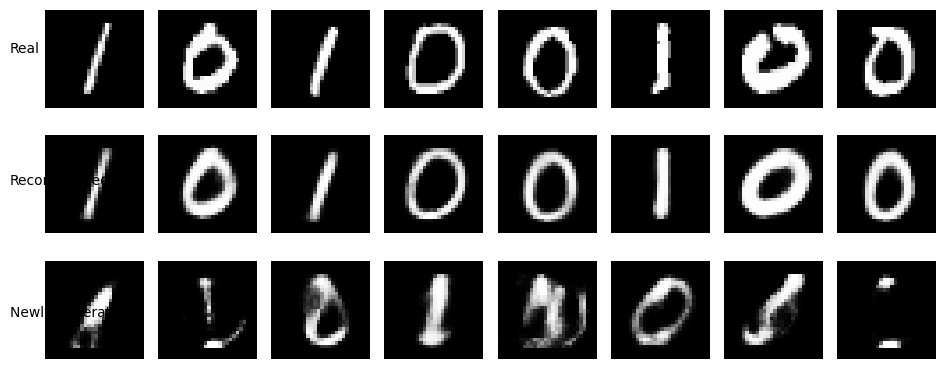

In [ ]:
# 4. Visual Comparison: Real vs Reconstructed vs Generated
fig, axes = plt.subplots(3, 8, figsize=(10, 4))
for k in range(8):
    axes[0, k].imshow(X_test[k].reshape(28, 28), cmap='gray'); axes[0, k].axis('off')
    axes[1, k].imshow(reconstructed[k].reshape(28, 28), cmap='gray'); axes[1, k].axis('off')
    axes[2, k].imshow(generated_images[k].reshape(28, 28), cmap='gray'); axes[2, k].axis('off')

plt.figtext(0.06, 0.83, 'Real', fontsize=10)
plt.figtext(0.06, 0.5, 'Reconstructed', fontsize=10)
plt.figtext(0.06, 0.17, 'Newly generated', fontsize=10)
plt.tight_layout(rect=[0.08, 0, 1, 1])
plt.show()

Written Reflection

What did the discriminative model learn?

The discriminative model (Logistic Regression) learned a decision boundary that separates images of 0s from images of 1s. It looked at pixel patterns and learned which combinations are typical of a 0 versus a 1, purely to tell the two classes apart. It reached about 99.95% accuracy, which makes sense since 0 and 1 look very different from each other.

What did the generative model learn?

The generative model (Autoencoder) learned the general structure of the digit images themselves — the typical shapes, curves, and strokes that make up 0s and 1s — without ever being told which digit was which. It did this by compressing each image into a small set of numbers (the latent representation) and learning to reconstruct the image back from that compressed form.

How are the two approaches different?

The discriminative model only cares about separating classes — it draws a line between "0" and "1" but has no idea what a digit actually looks like beyond that. The generative model instead tries to understand and recreate the data itself, which is why it can reconstruct existing digits and even generate new, synthetic ones, something the discriminative model cannot do at all. In short: the discriminative model learns where the boundary is, while the generative model learns what the data looks like.